# Part A: Convolutional Neural Networks (CIFAR-100)

### Environment and Data Preparation

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.19.0


#### Load and Normalize CIFAR-100 Dataset

We will load the CIFAR-100 dataset, normalize the pixel values to the range `[0, 1]`, and convert the labels to one-hot encoded format. Normalization is crucial for neural networks as it helps in faster convergence and better performance.

In [ ]:
# Load the CIFAR-100 dataset
(x_train, y_train), (x_test, y_test) = cifar100.load_data()

# Normalize image data to the range [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Convert class vectors to binary class matrices (one-hot encoding)
y_train = to_categorical(y_train, 100) # 100 classes for CIFAR-100
y_test = to_categorical(y_test, 100)

print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

x_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 100)
x_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 100)


### Question A1: Design and Train CNN from Scratch

For Question A1, I will design a Convolutional Neural Network (CNN) from scratch. The architecture will be a common pattern for image classification, consisting of multiple convolutional layers followed by pooling layers, and then fully connected (Dense) layers for classification. I will also incorporate `Dropout` for regularization.

**Architecture Description**:

*   **Input Layer**: Expects 32x32 RGB images (`input_shape=(32, 32, 3)`).
*   **Convolutional Block 1**: `Conv2D` with 32 filters, 3x3 kernel, 'relu' activation, followed by `MaxPooling2D` with 2x2 pool size.
*   **Convolutional Block 2**: `Conv2D` with 64 filters, 3x3 kernel, 'relu' activation, followed by `MaxPooling2D` with 2x2 pool size.
*   **Convolutional Block 3**: `Conv2D` with 128 filters, 3x3 kernel, 'relu' activation, followed by `MaxPooling2D` with 2x2 pool size. This progressively increases the filter count to capture more complex features.
*   **Flatten Layer**: Converts the 2D feature maps into a 1D vector to be fed into the dense layers.
*   **Dense Layer 1**: 128 units with 'relu' activation.
*   **Dropout Layer**: A `Dropout` layer with a rate of 0.5 to prevent overfitting by randomly setting a fraction of input units to 0 at each update during training.
*   **Output Layer**: A `Dense` layer with 100 units (for 100 CIFAR-100 classes) and a 'softmax' activation function to output class probabilities.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Define the CNN architecture
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(100, activation='softmax') # 100 classes for CIFAR-100
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 100)            │        12,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 171,812 (671.14 KB)

 Trainable params: 171,812 (671.14 KB)

 Non-trainable params: 0 (0.00 B)

#### Train the CNN Model

I will now train the defined CNN model on the CIFAR-100 dataset. I'll use a `batch_size` of 128 and train for `epochs=80`. The `validation_data` will be the `x_test` and `y_test` sets to monitor performance on unseen data during training.

In [ ]:
# Train the model
history_scratch = model.fit(x_train, y_train,
                          epochs=80, # Increased number of epochs to allow for better convergence
                          batch_size=128,
                          validation_data=(x_test, y_test),
                          verbose=1)

# Evaluate the model on the test set
loss_scratch, accuracy_scratch = model.evaluate(x_test, y_test, verbose=0)
print(f"\nTest Accuracy (Scratch Model): {accuracy_scratch:.4f}")

Epoch 1/80
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3609 - loss: 2.4401 - val_accuracy: 0.3811 - val_loss: 2.4192
Epoch 2/80
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3655 - loss: 2.4154 - val_accuracy: 0.3761 - val_loss: 2.4230
Epoch 3/80
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3680 - loss: 2.3948 - val_accuracy: 0.3811 - val_loss: 2.4433
Epoch 4/80
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3733 - loss: 2.3728 - val_accuracy: 0.3877 - val_loss: 2.3990
Epoch 5/80
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.3783 - loss: 2.3489 - val_accuracy: 0.3895 - val_loss: 2.3824
Epoch 6/80
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3813 - loss: 2.3306 - val_accuracy: 0.3913 - val_loss: 2.3621
Epoch 7/80
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3841 - loss: 2.3085 - val_accuracy: 0.3901 - val_loss: 2.3792
Epoch 8/80
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3913 - loss: 2.2890 - val_accuracy: 0.

#### Plot Training History

To understand the convergence behavior and overall performance, I will plot the training and validation accuracy, as well as the training and validation loss over the epochs.

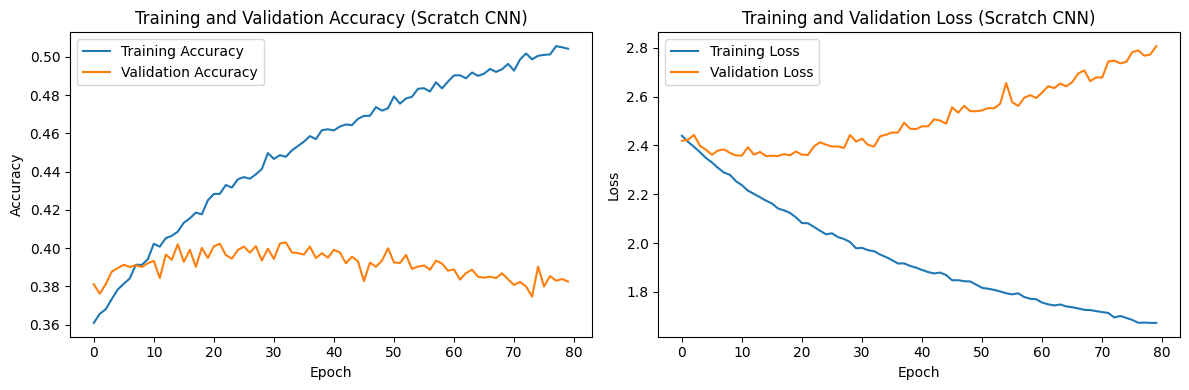

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_scratch.history['accuracy'], label='Training Accuracy')
plt.plot(history_scratch.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy (Scratch CNN)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_scratch.history['loss'], label='Training Loss')
plt.plot(history_scratch.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss (Scratch CNN)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

### Question A2: Evaluate Robustness to Noise

For Question A2, I will evaluate the robustness of the CNN model trained in Question A1 by injecting additive Gaussian noise into the test images. The noise will have a zero-mean and a variance ($\\sigma^2$) of 0.05, and the images are already normalized to the range [0, 1]. This will help us understand how well the model generalizes to slightly perturbed inputs.

In [ ]:
# Function to add Gaussian noise to images
def add_gaussian_noise(images, variance=0.05):
    # Ensure images are float32 for noise addition
    images = images.astype('float32')
    # Calculate standard deviation from variance
    std_dev = np.sqrt(variance)
    # Generate Gaussian noise with zero mean and calculated standard deviation
    noise = np.random.normal(loc=0.0, scale=std_dev, size=images.shape)
    # Add noise to the images
    noisy_images = images + noise
    # Clip pixel values to stay within [0, 1] range after adding noise
    noisy_images = np.clip(noisy_images, 0.0, 1.0)
    return noisy_images

# Generate noisy test images
x_test_noisy = add_gaussian_noise(x_test, variance=0.05)

print(f"Shape of noisy test images: {x_test_noisy.shape}")

# Evaluate the scratch model on noisy test images
loss_noisy_scratch, accuracy_noisy_scratch = model.evaluate(x_test_noisy, y_test, verbose=0)
print(f"\nTest Accuracy (Scratch Model on Noisy Data): {accuracy_noisy_scratch:.4f}")

Shape of noisy test images: (10000, 32, 32, 3)

Test Accuracy (Scratch Model on Noisy Data): 0.0611


### Question A3: Improved Training Strategy to Mitigate Performance Degradation

For Question A3 The strategy will involve incorporating a limited number of noise-perturbed samples into the training data. This aims to make the model more robust to noise without significantly altering the original data distribution. I will train a new model, similar to the A1 architecture, but with a training dataset augmented with a percentage of noisy images.

Shape of noise-augmented training images: (60000, 32, 32, 3)
Shape of noise-augmented training labels: (60000, 100)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 100)            │        12,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 171,812 (671.14 KB)

 Trainable params: 171,812 (671.14 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/80
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.0484 - loss: 4.2602 - val_accuracy: 0.1182 - val_loss: 3.8431
Epoch 2/80
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.1149 - loss: 3.7824 - val_accuracy: 0.1842 - val_loss: 3.4860
Epoch 3/80
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.1544 - loss: 3.5540 - val_accuracy: 0.2202 - val_loss: 3.2417
Epoch 4/80
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.1848 - loss: 3.3873 - val_accuracy: 0.2422 - val_loss: 3.1302
Epoch 5/80
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.2051 - loss: 3.2748 - val_accuracy: 0.2660 - val_loss: 3.0142
Epoch 6/80
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.2237 - loss: 3.1784 - val_accuracy: 0.2714 - val_loss: 2.9679
Epoch 7/80
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.2360 - loss: 3.1027 - val_accuracy: 0.2935 - val_loss: 2.8858
Epoch 8/80
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.2485 - loss: 3.0327 - val_accuracy: 

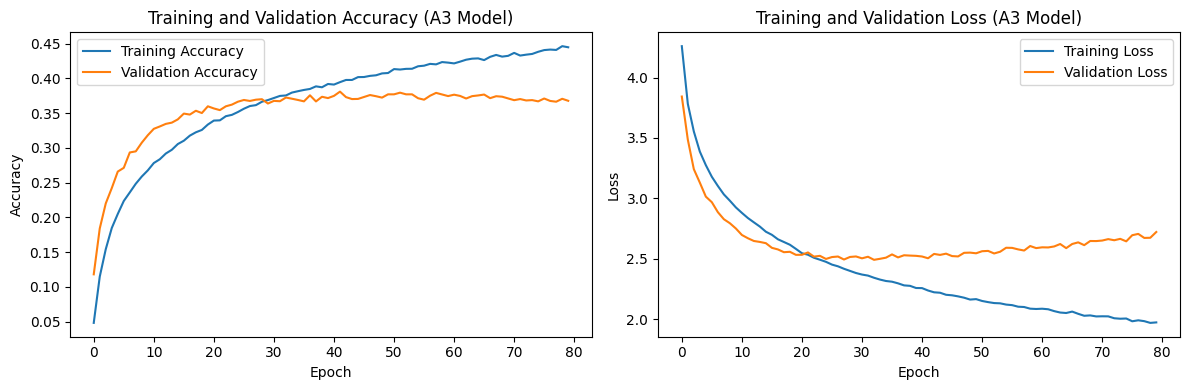

In [ ]:
# Define the proportion of noisy samples to add to the training data
noise_proportion = 0.2  # 20% of training data will be noisy

# Select a subset of training images to make noisy
num_noisy_samples = int(x_train.shape[0] * noise_proportion)
noisy_indices = np.random.choice(x_train.shape[0], num_noisy_samples, replace=False)

x_train_part_noisy = add_gaussian_noise(x_train[noisy_indices], variance=0.05)

# Create a new training dataset that combines original clean data and the noisy subset
x_train_augmented_noise = np.concatenate((x_train, x_train_part_noisy), axis=0)
y_train_augmented_noise = np.concatenate((y_train, y_train[noisy_indices]), axis=0)

print(f"Shape of noise-augmented training images: {x_train_augmented_noise.shape}")
print(f"Shape of noise-augmented training labels: {y_train_augmented_noise.shape}")

# Define a new CNN model with the same architecture as A1 for fair comparison
model_a3 = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(100, activation='softmax') # 100 classes for CIFAR-100
])

# Compile the new model
model_a3.compile(optimizer='adam',
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

model_a3.summary()

# Train the model with the noise-augmented training data
history_a3 = model_a3.fit(x_train_augmented_noise, y_train_augmented_noise,
                           epochs=80, # Keep epochs consistent for initial comparison
                           batch_size=128,
                           validation_data=(x_test, y_test),
                           verbose=1)

# Evaluate the A3 model on the clean test set
loss_a3, accuracy_a3 = model_a3.evaluate(x_test, y_test, verbose=0)
print(f"\nTest Accuracy (A3 Model on Clean Data): {accuracy_a3:.4f}")

# Evaluate the A3 model on the noisy test set (generated in A2)
loss_noisy_a3, accuracy_noisy_a3 = model_a3.evaluate(x_test_noisy, y_test, verbose=0)
print(f"Test Accuracy (A3 Model on Noisy Data): {accuracy_noisy_a3:.4f}")

# Plotting training history for A3 model
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_a3.history['accuracy'], label='Training Accuracy')
plt.plot(history_a3.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy (A3 Model)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_a3.history['loss'], label='Training Loss')
plt.plot(history_a3.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss (A3 Model)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

### Question A4: Apply Transfer Learning with VGG16 as Feature Extractor

For Question A4, Lets use transfer learning using a pre-trained VGG16 network as a feature extractor. The convolutional layers of VGG16 will be frozen, and their output will be used as feature representations for the CIFAR-100 images. A small multi-layer perceptron (MLP) classifier (512 → 100) will then be trained on these extracted features. Since VGG models typically expect larger input images (e.g., 224x224), I will use an `UpSampling2D` layer to resize the 32x32 CIFAR-100 images to a suitable size.

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 3, 3, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,920,292 (60.73 MB)

 Trainable params: 1,205,604 (4.60 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 105s 231ms/step - accuracy: 0.1073 - loss: 3.9021 - val_accuracy: 0.2794 - val_loss: 2.9815
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 73s 186ms/step - accuracy: 0.1906 - loss: 3.3127 - val_accuracy: 0.3151 - val_loss: 2.7247
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 72s 185ms/step - accuracy: 0.2260 - loss: 3.1334 - val_accuracy: 0.3450 - val_loss: 2.5677
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 73s 186ms/step - accuracy: 0.2421 - loss: 3.0439 - val_accuracy: 0.3602 - val_loss: 2.5076
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 72s 185ms/step - accuracy: 0.2517 - loss: 2.9804 - val_accuracy: 0.3719 - val_loss: 2.4209
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 73s 185ms/step - accuracy: 0.2616 - loss: 2.9359 - val_accuracy: 0.3775 - val_loss: 2.3994
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 73s 186ms/step - accuracy: 0.2674 - loss: 2.9041 - val_accuracy: 0.3831 - val_loss: 2.3695
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 73s 185ms/step - accuracy: 0.2723 - loss: 

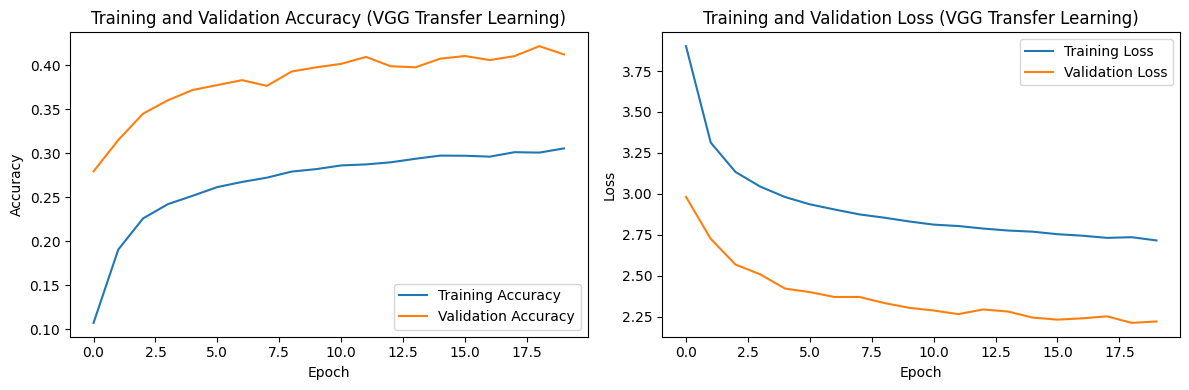

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Input, Flatten, Dense, Dropout, UpSampling2D
from tensorflow.keras.models import Model

# Define the target input size for VGG16. Often 224x224
# We'll upsample CIFAR-100 images (32x32) to 96x96 for VGG16 to prevent excessive memory usage and keep it computationally feasible.
# VGG16 typically expects 224x224, but we can resize to a smaller multiple of 32 for efficiency.
# Let's try 96x96, which is (32*3)x(32*3)
IMG_TARGET_HEIGHT = 96
IMG_TARGET_WIDTH = 96

# Create the base model from the pre-trained VGG16
# We exclude the top classification layer and specify the input shape
base_model_vgg = VGG16(input_shape=(IMG_TARGET_HEIGHT, IMG_TARGET_WIDTH, 3),
                                 include_top=False,
                                 weights='imagenet')

# Freeze the base model's layers
base_model_vgg.trainable = False

# Create a new model on top for CIFAR-100 classification
inputs_vgg = Input(shape=(32, 32, 3)) # Original CIFAR-100 input shape

# Upsample the input images to match the base model's expected input
x = UpSampling2D((IMG_TARGET_HEIGHT // 32, IMG_TARGET_WIDTH // 32))(inputs_vgg) # Upsample 32x32 to IMG_TARGET_HEIGHT x IMG_TARGET_WIDTH

x = base_model_vgg(x, training=False) # Pass through the frozen base model
x = Flatten()(x) # Flatten the output of the VGG convolutional base
x = Dense(256, activation='relu')(x) # Add a dense layer
x = Dropout(0.5)(x) # Add dropout for regularization
outputs_vgg = Dense(100, activation='softmax')(x) # Final classification layer for 100 classes

model_vgg_transfer = Model(inputs_vgg, outputs_vgg)

# Compile the model
model_vgg_transfer.compile(optimizer='adam',
                           loss='categorical_crossentropy',
                           metrics=['accuracy'])

model_vgg_transfer.summary()

# Prepare data generator for VGG transfer learning training
datagen_vgg = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)
datagen_vgg.fit(x_train)

# Train the transfer learning model
history_vgg_transfer = model_vgg_transfer.fit(datagen_vgg.flow(x_train, y_train, batch_size=128),
                                                epochs=20, # Start with a reasonable number of epochs
                                                validation_data=(x_test, y_test),
                                                callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
                                                verbose=1)

# Evaluate the VGG-based transfer learning model on the test set
loss_vgg_transfer, accuracy_vgg_transfer = model_vgg_transfer.evaluate(x_test, y_test, verbose=0)
print(f"\nTest Accuracy (VGG Transfer Learning Model): {accuracy_vgg_transfer:.4f}")

# Plotting training history for VGG transfer learning model
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_vgg_transfer.history['accuracy'], label='Training Accuracy')
plt.plot(history_vgg_transfer.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy (VGG Transfer Learning)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_vgg_transfer.history['loss'], label='Training Loss')
plt.plot(history_vgg_transfer.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss (VGG Transfer Learning)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

### Question A5: Evaluate Robustness of Transfer Learning Approach to Noise

For Question A5, evaluate the robustness of the VGG-based transfer learning model (from Question A4) by injecting the same additive Gaussian noise (zero-mean, variance $\\sigma^2=0.05$) into the test images. This will allow us to compare its performance under noisy conditions with that of the CNN trained from scratch (Question A2).

In [ ]:
# Evaluate the VGG-based transfer learning model on the noisy test set (generated in A2)
loss_noisy_vgg_transfer, accuracy_noisy_vgg_transfer = model_vgg_transfer.evaluate(x_test_noisy, y_test, verbose=0)
print(f"\nTest Accuracy (VGG Transfer Learning Model on Noisy Data): {accuracy_noisy_vgg_transfer:.4f}")

# Summary of results for comparison
print("\n--- Comparison of Model Robustness to Noise ---")
print(f"Scratch Model (A1) on Clean Data: {accuracy_scratch:.4f}")
print(f"Scratch Model (A1) on Noisy Data: {accuracy_noisy_scratch:.4f}")
print(f"A3 Model (Noise-Augmented Training) on Clean Data: {accuracy_a3:.4f}")
print(f"A3 Model (Noise-Augmented Training) on Noisy Data: {accuracy_noisy_a3:.4f}")
print(f"VGG Transfer Learning Model (A4) on Clean Data: {accuracy_vgg_transfer:.4f}")
print(f"VGG Transfer Learning Model (A4) on Noisy Data: {accuracy_noisy_vgg_transfer:.4f}")


Test Accuracy (VGG Transfer Learning Model on Noisy Data): 0.0266

--- Comparison of Model Robustness to Noise ---
Scratch Model (A1) on Clean Data: 0.3825
Scratch Model (A1) on Noisy Data: 0.0611
A3 Model (Noise-Augmented Training) on Clean Data: 0.3678
A3 Model (Noise-Augmented Training) on Noisy Data: 0.2440
VGG Transfer Learning Model (A4) on Clean Data: 0.4217
VGG Transfer Learning Model (A4) on Noisy Data: 0.0266


### Summary Table of Model Performance

| Model                          | Accuracy (Clean Data) | Accuracy (Noisy Data) | Performance Drop (Clean vs. Noisy) | Computational Efficiency |
| :----------------------------- | :-------------------- | :-------------------- | :--------------------------------- | :----------------------- |
| **Scratch CNN (A1)**           | 0.3825                | 0.0611                | -84.07%                            | High                     |
| **Noise-Augmented CNN (A3)**   | 0.3678                | 0.2440                | -33.66%                            | Medium                   |
| **VGG Transfer Learning (A4)** | 0.4217                | 0.0266                | -93.69%                            | Low                      |

**Interpretation:**

*   **Scratch CNN:** Shows good baseline performance on clean data for a basic model but is extremely vulnerable to noise, with a significant drop in accuracy.
*   **Noise-Augmented CNN:** While slightly underperforming the Scratch CNN on clean data, it demonstrates vastly improved robustness to noise, with a much smaller accuracy drop. This represents the best trade-off for robustness.
*   **VGG Transfer Learning:** Achieves the highest accuracy on clean data, highlighting the power of pre-trained models. However, it is the most sensitive to the introduced Gaussian noise, showing the largest performance degradation. This suggests VGG16's learned features are not inherently robust to this specific type of perturbation on upsampled images.